In [1]:
!pip install -q pandas
!pip install -q numpy
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q plotly
!pip install -q sklearn
!pip install -q imblearn
!pip install -q xgboost
!pip install -q catboost
!pip install -q lightgbm

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 MB 12.9 MB/s eta 0:00:00


In [2]:
#importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
#import squarify
import csv
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)

import urllib, os, pickle
%matplotlib inline
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import preprocessing 
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn import compose
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector

from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import NearMiss
# Profiling
import pandas_profiling
from pandas_profiling import ProfileReport
# Models
import xgboost
import catboost  
import lightgbm  
from sklearn import tree
from sklearn import linear_model 
from sklearn import svm 
from sklearn import neighbors 
from sklearn import ensemble 
from sklearn.dummy import DummyRegressor
from sklearn.base import clone
from sklearn.utils import all_estimators
# Setup reproductibility
np.random.seed(0)

In [3]:
#moounting and accessing my folder named 'file'
from google.colab import drive

drive.mount('/content/gdrive/', force_remount=True)
%cd gdrive/MyDrive/files

Mounted at /content/gdrive/
/content/gdrive/MyDrive/files


In [4]:
#checking for files in my folder
for file in os.listdir():
  print(file)

Test2.csv
Train2.csv
uploaded1
uploaded
train_label1.csv
eval_label1.csv
flagged
test.csv
train.csv
VariableDefinitions.csv
SampleSubmission1.csv
Test3.csv
Train3.csv
StarterNotebook.ipynb
ml_cp.pkl
ml_com.pkl
Capstone_Project_Customer_Churn4.ipynb
Capstone_Project_Customer_Churn_L.ipynb


# Data reading

In [5]:
Train = pd.read_csv('Train3.csv')
Test = pd.read_csv('Test3.csv')
submission = pd.read_csv('SampleSubmission1.csv')
variable= pd.read_csv('VariableDefinitions.csv')

In [6]:
variable

,Variable Definitions,Unnamed: 1,Unnamed: 2
0,NaN,French,English
1,NaN,Le dataset churn comprend 19 variables dont 15...,The churn dataset includes 19 variables includ...
2,user_id,NaN,NaN
3,REGION,la localité de chaque client,the location of each client
4,TENURE,la durée dans le reseau,duration in the network
5,MONTANT,montant de recharge,top-up amount
6,FREQUENCE_RECH,nombre de fois que le client a fait une recharge,number of times the customer refilled
7,REVENUE,revenu mensuel de chaque client,monthly income of each client
8,ARPU_SEGMENT,revenu sur 90 jours/3,income over 90 days / 3
9,FREQUENCE,nombre de fois que client à fait un revenu,number of times the client has made an income


In [7]:
Train

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,7ee9e11e342e27c70455960acc80d3f91c1286d1,DAKAR,K > 24 month,20000.0,47.0,21602.0,7201.0,52.0,8835.0,3391.0,396.0,185.0,NaN,NaN,NO,62,On net 200F=Unlimited _call24H,30.0,0
1,50443f42bdc92b10388fc56e520e4421a5fa655c,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,3,NaN,NaN,0
2,da90b5c1a9b204c186079f89969aa01cb03c91b2,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,0
3,364ec1b424cdc64c25441a444a16930289a0051e,SAINT-LOUIS,K > 24 month,7900.0,19.0,7896.0,2632.0,25.0,9385.0,27.0,46.0,20.0,NaN,2.0,NO,61,"Data:490F=1GB,7d",7.0,0
4,d5a5247005bc6d41d3d99f4ef312ebb5f640f2cb,DAKAR,K > 24 month,12350.0,21.0,12351.0,4117.0,29.0,9360.0,66.0,102.0,34.0,NaN,NaN,NO,56,All-net 500F=2000F;5d,11.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077019,56e22fe3312a48cf860b043a021dab275383a20a,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,16,NaN,NaN,0
1077020,587b72930e4d36b3fb94a18c3ef65c2079460eee,TAMBACOUNDA,K > 24 month,2500.0,5.0,2500.0,833.0,5.0,0.0,15.0,77.0,NaN,NaN,NaN,NO,34,All-net 500F=2000F;5d,2.0,0
1077021,d6831b8edacb7d9928b3f053fb1283574577ae42,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,3,NaN,NaN,1
1077022,cb1f6510b084173c0deae49095f35ac29f916701,NaN,K > 24 month,600.0,1.0,600.0,200.0,1.0,591.0,11.0,37.0,5.0,1.0,NaN,NO,16,All-net 600F= 3000F ;5d,1.0,0


In [8]:
Test

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK
0,51fe4c3347db1f8571d18ac03f716c41acee30a4,MATAM,I 18-21 month,2500.0,5.0,2500.0,833.0,5.0,0.0,64.0,70.0,NaN,NaN,NaN,NO,35,All-net 500F=2000F;5d,5.0
1,5ad5d67c175bce107cc97b98c4e37dcc38aa7f3e,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,2,NaN,NaN
2,5a4db591c953a8d8f373877fad37aaf4268899a1,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NO,22,NaN,NaN
3,8bf9b4d8880aeba1c9a0da48be78f12e629be37c,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,6,NaN,NaN
4,c7cdf2af01e9fa95bf498b68c122aa4b9a8d10df,SAINT-LOUIS,K > 24 month,5100.0,7.0,5637.0,1879.0,15.0,7783.0,30.0,24.0,0.0,0.0,NaN,NO,60,"Data:1000F=2GB,30d",4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190058,1092956a3dad77ceb7e8d7c70e3e13f77b60e2aa,DAKAR,F 9-12 month,500.0,1.0,506.0,169.0,1.0,0.0,26.0,NaN,NaN,6.0,NaN,NO,14,All-net 500F=2000F;5d,1.0
190059,bec10becca7faa8e9cab9981b3aee5e9a7f04828,DAKAR,K > 24 month,2000.0,4.0,2000.0,667.0,5.0,0.0,8.0,54.0,NaN,NaN,NaN,NO,29,All-net 500F =2000F_AllNet_Unlimited,3.0
190060,7ac6fc191f8732b1b146e57f9ede983626b93eae,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,2,NaN,NaN
190061,d592c81971d6120b0d19f9ace85f278ea21b89a0,NaN,K > 24 month,300.0,2.0,298.0,99.0,2.0,0.0,1.0,2.0,NaN,NaN,NaN,NO,12,NaN,NaN


In [9]:
submission

,user_id,CHURN
0,51fe4c3347db1f8571d18ac03f716c41acee30a4,0
1,5ad5d67c175bce107cc97b98c4e37dcc38aa7f3e,0
2,5a4db591c953a8d8f373877fad37aaf4268899a1,0
3,8bf9b4d8880aeba1c9a0da48be78f12e629be37c,0
4,c7cdf2af01e9fa95bf498b68c122aa4b9a8d10df,0
...,...,...
190058,1092956a3dad77ceb7e8d7c70e3e13f77b60e2aa,0
190059,bec10becca7faa8e9cab9981b3aee5e9a7f04828,0
190060,7ac6fc191f8732b1b146e57f9ede983626b93eae,0
190061,d592c81971d6120b0d19f9ace85f278ea21b89a0,0


# VISUALIZATIONS

In [10]:
#copying train data for visualization
df = Train.copy()
df

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,7ee9e11e342e27c70455960acc80d3f91c1286d1,DAKAR,K > 24 month,20000.0,47.0,21602.0,7201.0,52.0,8835.0,3391.0,396.0,185.0,NaN,NaN,NO,62,On net 200F=Unlimited _call24H,30.0,0
1,50443f42bdc92b10388fc56e520e4421a5fa655c,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,3,NaN,NaN,0
2,da90b5c1a9b204c186079f89969aa01cb03c91b2,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,0
3,364ec1b424cdc64c25441a444a16930289a0051e,SAINT-LOUIS,K > 24 month,7900.0,19.0,7896.0,2632.0,25.0,9385.0,27.0,46.0,20.0,NaN,2.0,NO,61,"Data:490F=1GB,7d",7.0,0
4,d5a5247005bc6d41d3d99f4ef312ebb5f640f2cb,DAKAR,K > 24 month,12350.0,21.0,12351.0,4117.0,29.0,9360.0,66.0,102.0,34.0,NaN,NaN,NO,56,All-net 500F=2000F;5d,11.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077019,56e22fe3312a48cf860b043a021dab275383a20a,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,16,NaN,NaN,0
1077020,587b72930e4d36b3fb94a18c3ef65c2079460eee,TAMBACOUNDA,K > 24 month,2500.0,5.0,2500.0,833.0,5.0,0.0,15.0,77.0,NaN,NaN,NaN,NO,34,All-net 500F=2000F;5d,2.0,0
1077021,d6831b8edacb7d9928b3f053fb1283574577ae42,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,3,NaN,NaN,1
1077022,cb1f6510b084173c0deae49095f35ac29f916701,NaN,K > 24 month,600.0,1.0,600.0,200.0,1.0,591.0,11.0,37.0,5.0,1.0,NaN,NO,16,All-net 600F= 3000F ;5d,1.0,0


In [11]:
df['CHURN']= df['CHURN'].replace(0,'No')
df['CHURN']= df['CHURN'].replace(1,'Yes')
df

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,7ee9e11e342e27c70455960acc80d3f91c1286d1,DAKAR,K > 24 month,20000.0,47.0,21602.0,7201.0,52.0,8835.0,3391.0,396.0,185.0,NaN,NaN,NO,62,On net 200F=Unlimited _call24H,30.0,No
1,50443f42bdc92b10388fc56e520e4421a5fa655c,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,3,NaN,NaN,No
2,da90b5c1a9b204c186079f89969aa01cb03c91b2,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,No
3,364ec1b424cdc64c25441a444a16930289a0051e,SAINT-LOUIS,K > 24 month,7900.0,19.0,7896.0,2632.0,25.0,9385.0,27.0,46.0,20.0,NaN,2.0,NO,61,"Data:490F=1GB,7d",7.0,No
4,d5a5247005bc6d41d3d99f4ef312ebb5f640f2cb,DAKAR,K > 24 month,12350.0,21.0,12351.0,4117.0,29.0,9360.0,66.0,102.0,34.0,NaN,NaN,NO,56,All-net 500F=2000F;5d,11.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077019,56e22fe3312a48cf860b043a021dab275383a20a,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,16,NaN,NaN,No
1077020,587b72930e4d36b3fb94a18c3ef65c2079460eee,TAMBACOUNDA,K > 24 month,2500.0,5.0,2500.0,833.0,5.0,0.0,15.0,77.0,NaN,NaN,NaN,NO,34,All-net 500F=2000F;5d,2.0,No
1077021,d6831b8edacb7d9928b3f053fb1283574577ae42,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,3,NaN,NaN,Yes
1077022,cb1f6510b084173c0deae49095f35ac29f916701,NaN,K > 24 month,600.0,1.0,600.0,200.0,1.0,591.0,11.0,37.0,5.0,1.0,NaN,NO,16,All-net 600F= 3000F ;5d,1.0,No


### What is the total percentage/ number of those who churn?

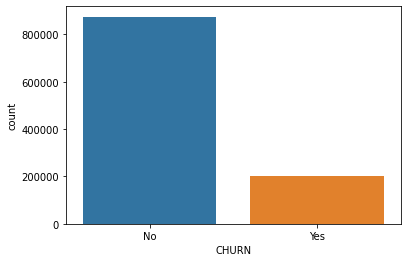

In [12]:
#churn count
sns.countplot(data=df, x='CHURN')

#Churn percentage
fig1 = go.Figure(
    data=go.Pie(values=df['CHURN'].value_counts().values,labels=df['CHURN'].value_counts().index,title='percentage of those who churn'))
fig1.show()
plt.show()
rcParams['figure.figsize'] = 15,8

#plt.tight_layout

We are having those who don't churn to have a percentage of 18.8(201,993) and those who churn to be 81.2(875,031)

In [13]:
def tenure_group_counts(df):
    plt.figure(figsize = (13,10))
    t = sns.countplot(data = df, x = 'TENURE', hue = 'CHURN')
    t.set_title('Churn Counts by Tenure Groups', fontsize = 30, fontweight = 'bold')
    t.set_xlabel('Tenure Groups',fontsize = 20, fontweight = 'bold', labelpad = 1.5)
    t.set_ylabel('Count', fontsize = 20, fontweight = 'bold')
    t.legend(loc = 'upper right', fontsize = 20, labels = ['No Churn', 'Churn'], edgecolor = 'black', bbox_to_anchor = (1.2, 1))
    plt.tight_layout()

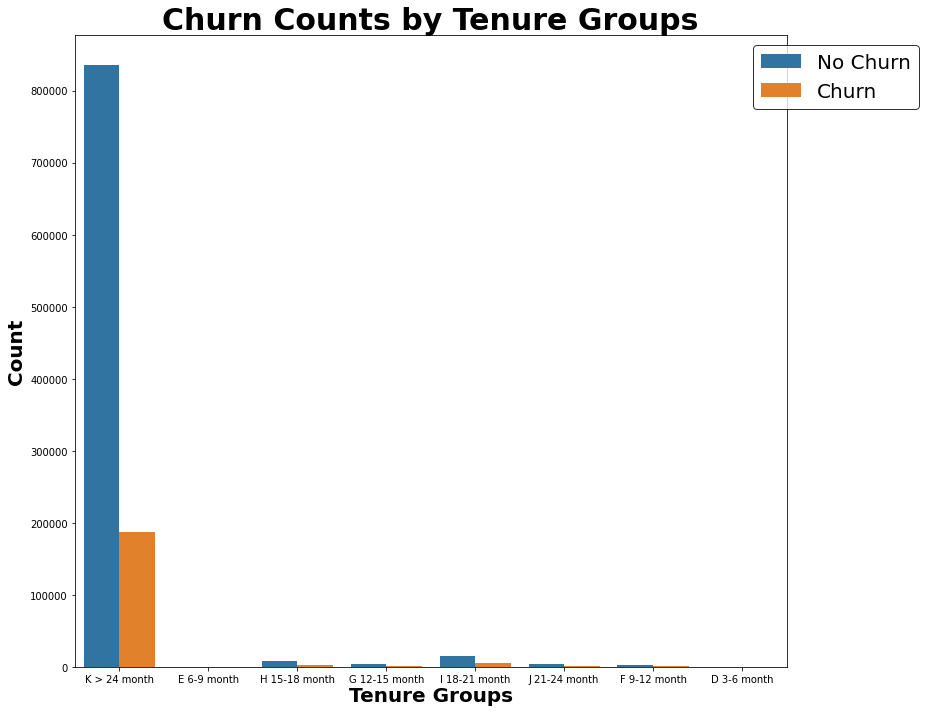

In [14]:
tenure_group_counts(df)

**Customers with shorter service tenures (newer clients) are more likely to churn than those with longer tenures....so most of the people who left service had less tenure**



In [15]:
def plot_montant_averages(df):
    fig = plt.figure(figsize = (13, 10))
    b = sns.barplot(data = df, x = 'TENURE', y = 'MONTANT', hue = 'CHURN')
    b.set_ylabel(f' ($)', fontsize = 20, fontweight = 'bold')
    b.set_title(f'Average MONTANT by Tenure Group', fontsize = 30, fontweight = 'bold')
    b.legend(fontsize = 20, loc = 'upper left',labels = ['No Churn', 'Churn'], edgecolor = 'black')
    plt.tight_layout()



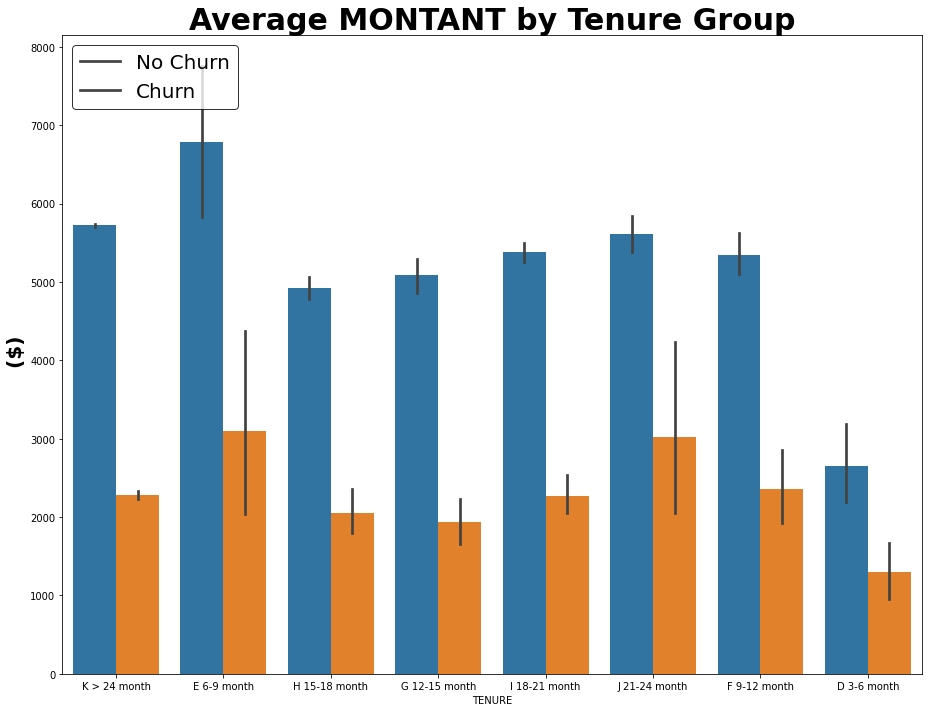

In [16]:
plot_montant_averages(df)

**Those who have been staying with the company between 6-9 months Churn most, and they are also the people with high top-up-amount**

In [17]:
def plot_revenue_averages(df):
    fig = plt.figure(figsize = (13, 10))
    b = sns.barplot(data = df, x = 'TENURE', y = 'REVENUE', hue = 'CHURN')
    b.set_ylabel(f' REVENUE ($)', fontsize = 20, fontweight = 'bold')
    b.set_title(f'Average REVENUE by Tenure Group', fontsize = 30, fontweight = 'bold')
    b.legend(fontsize = 20, loc = 'upper left',labels = ['No Churn', 'Churn'], edgecolor = 'black')
    plt.tight_layout()

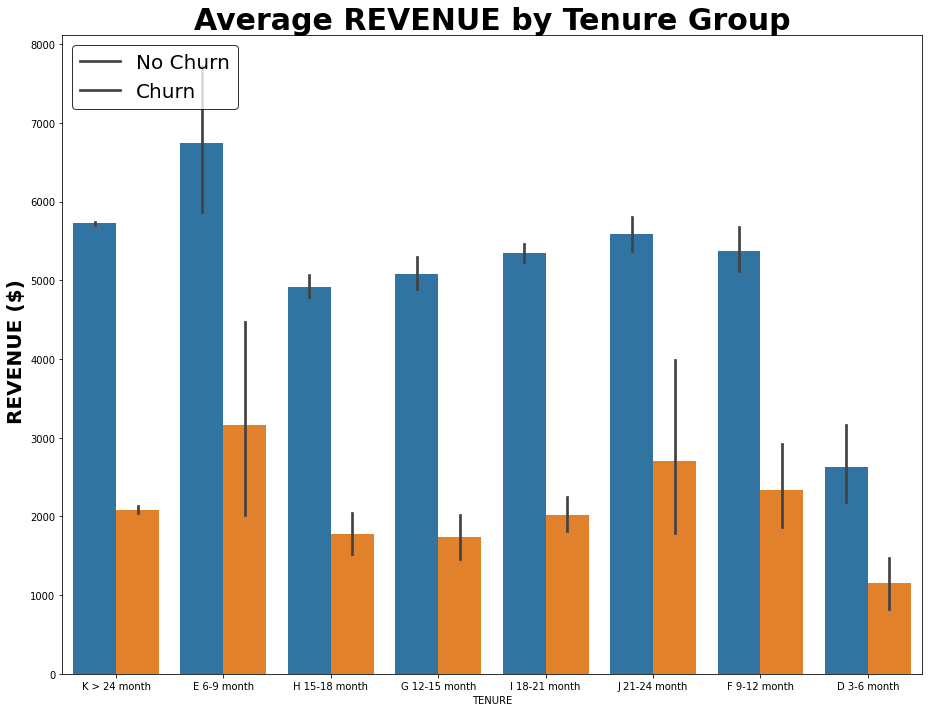

In [18]:
plot_revenue_averages(df)

**INTERESTING! Tenure group between 6-9 months are those with highh revenue. No wonder their top-up-amount is also high...They are those who churn most also**

In [19]:

def plot_refilled_averages(df):
    fig = plt.figure(figsize = (13, 10))
    b = sns.barplot(data = df, x = 'TENURE', y = 'FREQUENCE_RECH', hue = 'CHURN')
    b.set_ylabel(f' Times the customer refilled ', fontsize = 20, fontweight = 'bold')
    b.set_title(f'Average times the customer refilled by Tenure Group', fontsize = 30, fontweight = 'bold')
    b.legend(fontsize = 20, loc = 'upper left',labels = ['No Churn', 'Churn'], edgecolor = 'black')
    plt.tight_layout()

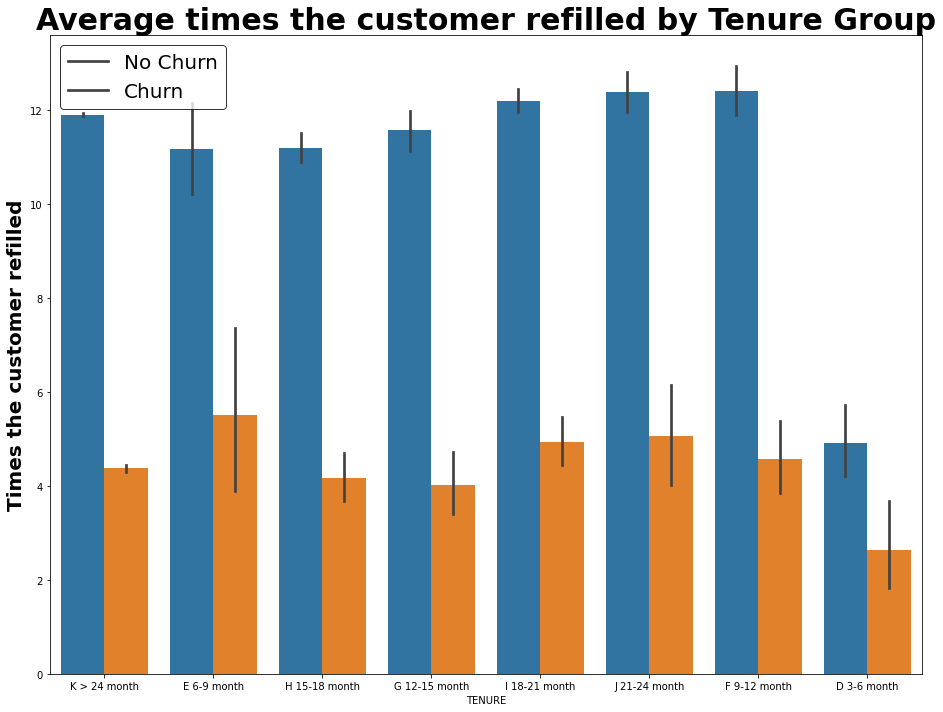

In [20]:
plot_refilled_averages(df)

**Those with Tenure between 9-12 refilled frequently with respect to those who don't churn** 

In [21]:
def plot_re_mon_averages(df):
    fig = plt.figure(figsize = (13, 10))
    b = sns.barplot(data = df, x = 'REGION', y = 'REVENUE', hue = 'CHURN')
    b.set_ylabel(f' REVENUE ', fontsize = 20, fontweight = 'bold')
    b.set_title(f'Average REVENUE by REGION', fontsize = 30, fontweight = 'bold')
    b.legend(fontsize = 20, loc = 'upper left', edgecolor = 'black')
    plt.tight_layout()

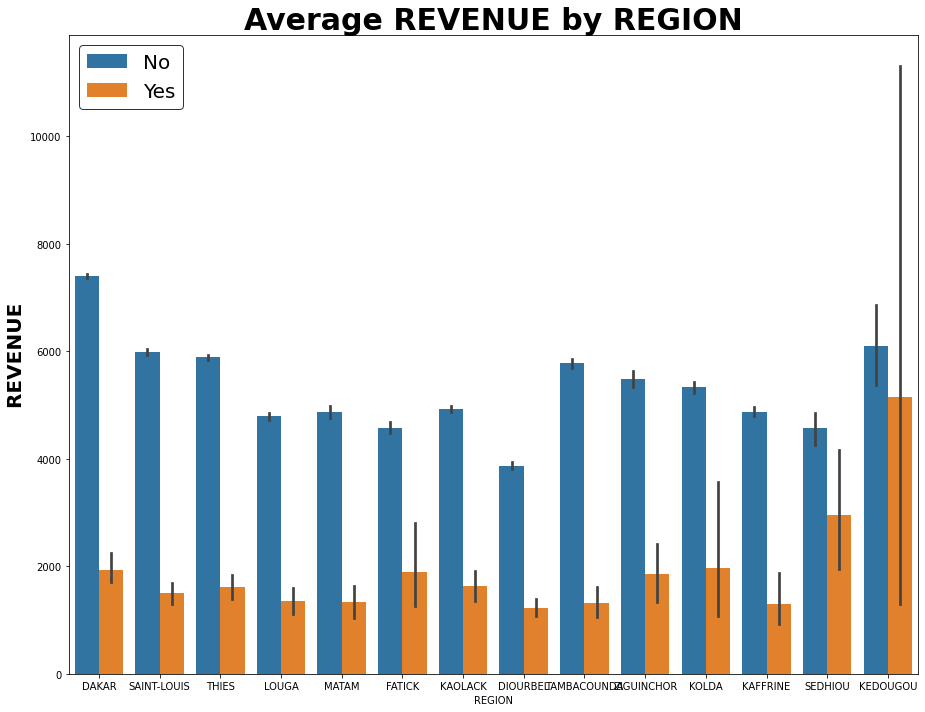

In [22]:
plot_re_mon_averages(df)

**The highest Revenue is coming from DAKAR with respect to those who don't churn...And respect to those who churn, the highest Revenue is coming from KEDOUGOU**

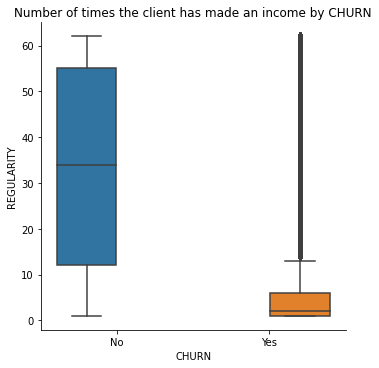

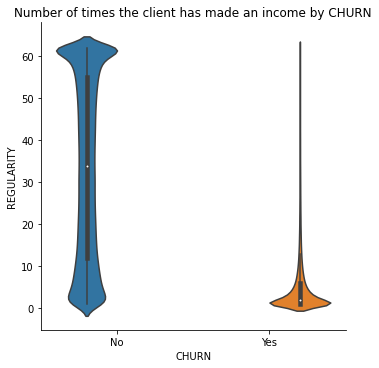

In [23]:
sns.catplot(data= df, x='CHURN',y='REGULARITY',kind='box', hue='CHURN').set(title='Number of times the client has made an income by CHURN')
sns.catplot(data= df, x='CHURN',y='REGULARITY',kind='violin', hue='CHURN').set(title='Number of times the client has made an income by CHURN')

**It can be seen that client churn when the Number of times a he or she  has made an income is between 0-10**

# FEATURE ENGINEERING

## Dropping unwanted features


In [24]:
Train.drop(columns=['user_id','REGION', 'MRG', 'TOP_PACK'], inplace=True) 
Test.drop(columns=['user_id','REGION', 'MRG', 'TOP_PACK'], inplace=True)

In [25]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077024 entries, 0 to 1077023
Data columns (total 15 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   TENURE          1077024 non-null  object 
 1   MONTANT         699139 non-null   float64
 2   FREQUENCE_RECH  699139 non-null   float64
 3   REVENUE         714669 non-null   float64
 4   ARPU_SEGMENT    714669 non-null   float64
 5   FREQUENCE       714669 non-null   float64
 6   DATA_VOLUME     547261 non-null   float64
 7   ON_NET          683850 non-null   float64
 8   ORANGE          629880 non-null   float64
 9   TIGO            432250 non-null   float64
 10  ZONE1           84898 non-null    float64
 11  ZONE2           68794 non-null    float64
 12  REGULARITY      1077024 non-null  int64  
 13  FREQ_TOP_PACK   626129 non-null   float64
 14  CHURN           1077024 non-null  int64  
dtypes: float64(12), int64(2), object(1)
memory usage: 123.3+ MB


### Defining variables for the columns in the dataframe to perform a train test split.

In [26]:
num_cols = Train.select_dtypes(include=np.number).columns.tolist()
cat_cols = Train.select_dtypes(exclude=np.number).columns.tolist()

print( f"Numeric features : {len(num_cols)}" )
print( f"Categorical features : {len(cat_cols)}" )

Numeric features : 14
Categorical features : 1


In [27]:
columns = ['TENURE','MONTANT', 'FREQUENCE_RECH','REVENUE','ARPU_SEGMENT','FREQUENCE','DATA_VOLUME','ON_NET','ORANGE','TIGO','ZONE1','ZONE2','REGULARITY','FREQ_TOP_PACK']
numerical_columns = ['MONTANT', 'FREQUENCE_RECH','REVENUE','ARPU_SEGMENT','FREQUENCE','DATA_VOLUME','ON_NET','ORANGE','TIGO','ZONE1','ZONE2','REGULARITY','FREQ_TOP_PACK']
categorical_columns = ['TENURE']

### Splitting Data into Predictor and Response Variable

In [28]:
X = Train.drop(['CHURN'], axis=1)
y = Train.CHURN

### Splitting Data into Train and Test data

In [29]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y,test_size=0.2, random_state=42,stratify=y)
(X_train.shape, y_train.shape) , ( X_eval.shape,  y_eval.shape)

(((861619, 14), (861619,)), ((215405, 14), (215405,)))

In [ ]:
 # Pipeline for the Numeric features 
num_transformer = Pipeline(
     steps=[("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())]
 )

 # Pipeline for the Categorical features
encoder_categories = [ Train[categorical_columns[i] ].append( Test[categorical_columns[i] ] ).dropna().unique() for i in range(len(categorical_columns)) ]

cat_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", preprocessing.OneHotEncoder(categories=encoder_categories, drop="first", sparse=False)) #if_binary
            
            ])

 # Associate the two pipelines
preprocessor = ColumnTransformer(
     transformers=[
         ("num", num_transformer, selector(dtype_include="number")),
         ("cat", cat_transformer, selector(dtype_exclude="number")),
        
     ]
 )
X_train__, X_eval__ = preprocessor.fit_transform(X_train), preprocessor.transform(X_eval)
 # New categorical feature names
feature_names_out = preprocessor.named_transformers_['cat'][-1].get_feature_names_out().tolist()
indexes = [ int(feature_names_out[i][1:feature_names_out[i].find("_")]) for i in range(len(feature_names_out))]
cat_cols_encoded = [  col.replace( f"x{i}", categorical_columns[i] )  for col,i in zip(feature_names_out, indexes)]

 # train df
df_X_train = pd.DataFrame(X_train__, columns=numerical_columns+cat_cols_encoded)

 # eval df
df_X_eval = pd.DataFrame(X_eval__, columns=numerical_columns+cat_cols_encoded)



In [31]:
df_X_train

,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,TENURE_E 6-9 month,TENURE_H 15-18 month,TENURE_G 12-15 month,TENURE_I 18-21 month,TENURE_J 21-24 month,TENURE_F 9-12 month,TENURE_D 3-6 month
0,-3.172038e-16,-1.662200e-16,-4.663622e-16,4.663629e-16,-1.484145e-16,-9.932339e-17,-4.082602e-16,9.104350e-17,-3.457575e-16,-1.600053e-16,1.941584e-16,-1.124118,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-4.016723e-02,1.379977e-01,-3.495233e-02,-3.512629e-02,2.523099e-01,5.463112e-01,-4.082602e-16,-5.851897e-01,-5.631130e-01,-1.600053e-16,1.941584e-16,-1.124118,-0.242199,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-8.772135e-01,-9.848846e-01,-8.557272e-01,-8.555606e-01,-1.084489e+00,-3.529011e-01,-3.832147e-01,-5.659699e-01,-3.457575e-16,-1.600053e-16,1.941584e-16,-0.630643,-0.883486,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-9.248262e-02,-2.362964e-01,-8.657124e-02,-8.640344e-02,-4.160896e-01,-9.932339e-17,3.187086e-03,-3.865846e-01,-1.981552e-01,-1.600053e-16,1.941584e-16,0.894642,-0.242199,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-3.172038e-16,-1.662200e-16,-9.377706e-01,-9.376040e-01,-1.084489e+00,-9.932339e-17,-4.082602e-16,-6.108162e-01,-3.457575e-16,-1.600053e-16,1.941584e-16,-1.213840,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
861614,-7.028289e-01,-7.977375e-01,-6.848037e-01,-6.848077e-01,-7.502893e-01,-6.710579e-02,-4.082602e-16,-6.108162e-01,-5.631130e-01,-1.600053e-16,1.941584e-16,0.266583,-0.669724,0.0,0.0,0.0,0.0,0.0,0.0,0.0
861615,-8.772135e-01,-9.848846e-01,-7.702655e-01,-7.704405e-01,-1.000939e+00,-3.662244e-01,-3.832147e-01,-4.762773e-01,-3.457575e-16,-1.600053e-16,1.941584e-16,1.074087,-0.883486,0.0,0.0,0.0,0.0,0.0,0.0,0.0
861616,1.686241e+00,2.383762e+00,1.846745e+00,1.846745e+00,2.173958e+00,-3.677533e-01,3.335678e-01,2.361854e+00,-5.144520e-01,-7.367714e-01,-6.217504e-01,1.477839,1.040373,0.0,0.0,0.0,0.0,0.0,0.0,0.0
861617,-1.447980e-01,2.315712e-01,-1.356263e-01,-1.356295e-01,8.521003e-02,3.224364e-01,-3.128742e-02,-2.904854e-01,-1.981552e-01,-7.367714e-01,1.941584e-16,0.804919,-0.028437,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
df_X_eval

,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,TENURE_E 6-9 month,TENURE_H 15-18 month,TENURE_G 12-15 month,TENURE_I 18-21 month,TENURE_J 21-24 month,TENURE_F 9-12 month,TENURE_D 3-6 month
0,-9.295289e-01,-9.848846e-01,-4.663622e-16,4.663629e-16,-1.484145e-16,-9.932339e-17,-4.082602e-16,9.104350e-17,-3.457575e-16,-1.600053e-16,1.941584e-16,-1.213840,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-3.172038e-16,-1.662200e-16,-4.663622e-16,4.663629e-16,-1.484145e-16,-9.932339e-17,-4.082602e-16,9.104350e-17,-3.457575e-16,-1.600053e-16,1.941584e-16,-1.168979,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.738556e+00,7.930123e-01,1.536861e+00,1.537031e+00,1.254909e+00,-9.932339e-17,5.058953e-02,8.109837e-02,1.042701e+00,-1.600053e-16,1.941584e-16,1.477839,1.467898,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-7.551443e-01,-5.170170e-01,-7.359098e-01,-7.360849e-01,2.523099e-01,-9.932339e-17,-3.803418e-01,-5.851897e-01,-5.631130e-01,-1.600053e-16,1.941584e-16,0.670335,-0.883486,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-4.238134e-01,-2.362964e-01,-4.116678e-01,-4.115005e-01,-3.325396e-01,-9.932339e-17,-2.955920e-01,-2.968920e-01,-1.981552e-01,-1.600053e-16,1.941584e-16,0.760058,-0.562842,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215400,1.311314e+00,6.058652e-01,1.236548e+00,1.236547e+00,1.756209e+00,1.183535e+00,-3.975790e-01,-5.275302e-01,-3.198078e-01,-1.600053e-16,1.941584e-16,1.343255,0.826611,0.0,0.0,0.0,0.0,0.0,0.0,0.0
215401,-8.772135e-01,-9.848846e-01,-8.557272e-01,-8.555606e-01,-1.084489e+00,-3.677533e-01,-3.903969e-01,-5.019037e-01,-3.457575e-16,-1.600053e-16,1.941584e-16,0.984364,-0.883486,0.0,0.0,0.0,0.0,0.0,0.0,0.0
215402,-5.458827e-01,-3.298699e-01,-5.526798e-01,-5.525127e-01,-4.996395e-01,-3.677533e-01,-3.688503e-01,9.104350e-17,-3.457575e-16,-1.600053e-16,1.941584e-16,0.176860,-0.455961,0.0,0.0,0.0,0.0,0.0,0.0,0.0
215403,-3.172038e-16,-1.662200e-16,-4.663622e-16,4.663629e-16,-1.484145e-16,-9.932339e-17,-4.082602e-16,9.104350e-17,-3.457575e-16,-1.600053e-16,1.941584e-16,-1.213840,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model Building

## 1. Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
classifier1= LogisticRegression(random_state = 24)
log_model=classifier1.fit(df_X_train, y_train)

In [34]:
#feature imporance of the logistic regression
reg_importance = log_model.coef_[0]
reg_importance = pd.DataFrame(reg_importance, index =df_X_train.columns)
reg_importance.reset_index(inplace = True)
reg_importance.rename(columns={'index':'Feature', 0 : 'Score'},inplace = True)
reg_importance.sort_values('Score',ascending= False, inplace=True)
reg_importance

#visualizing feature importance
figure= px.bar(reg_importance, x ='Feature', y= 'Score').update_xaxes(categoryorder='total descending')
figure.show()

In [35]:

# import the class
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

logreg = LogisticRegression()

# fit the model with data
logreg.fit(df_X_train, y_train)

#predicting test set result
y_pred = logreg.predict(df_X_eval)

#evaluate results
acc = accuracy_score(y_eval,y_pred)
prec = precision_score(y_eval,y_pred)
rec = recall_score(y_eval, y_pred)
f1 = f1_score(y_eval,y_pred)
f2 = fbeta_score(y_eval,y_pred,beta=2.0)

results = pd.DataFrame([['Logistics Regression',acc,prec,rec,f1,f2]],columns=['Model', 'Accuracy','Precision','Recall','F1 score','F2 score'])
results

,Model,Accuracy,Precision,Recall,F1 score,F2 score
0,Logistics Regression,0.85725,0.625488,0.595312,0.610027,0.601112


## Model Evaluation 

In [36]:

#defining confusion metrics
cnf_matrix = metrics.confusion_matrix(y_eval, y_pred)
cnf_matrix =pd.DataFrame(cnf_matrix).reset_index(drop =True)
cnf_matrix

,0,1
0,160606,14400
1,16349,24050


## Visualizing Confusion Matrix using Heatmap

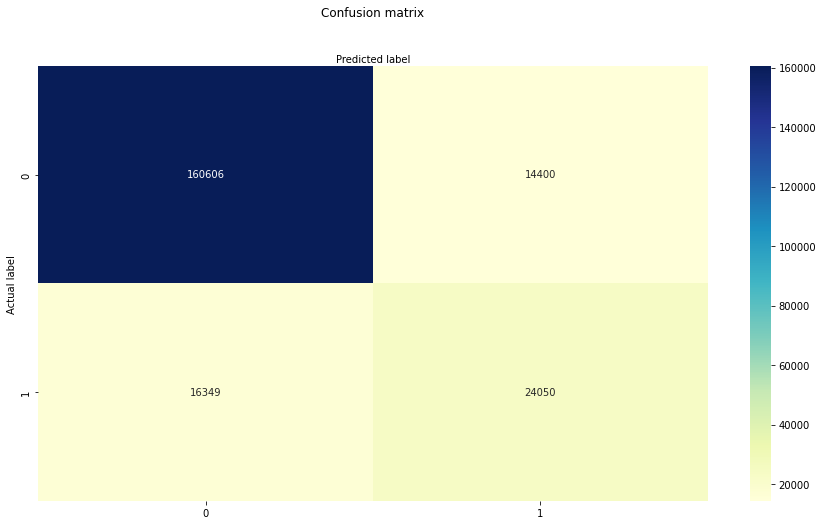

In [37]:
#visualizing confusion metrics
fig, ax = plt.subplots()
sns.heatmap(cnf_matrix, annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
ax.xaxis.set_label_position("top")


## 2. Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree classifer object
clf1 = DecisionTreeClassifier()

# Train Decision Tree Classifer with train set
clf_ = clf1.fit(df_X_train, y_train)

In [44]:
# Feature Importance of the Model
dt_importance = clf_.feature_importances_
dt_importance = pd.DataFrame(dt_importance,
                                columns=["score"]).reset_index()
dt_importance["Feature"] = list(df_X_train.columns)
dt_importance.drop(columns=["index"], inplace=True)
dt_importance.sort_values(by="score",
                             ascending=False,
                             ignore_index=True,
                             inplace=True)

fig = px.bar(dt_importance, x="Feature", y="score")
fig.show()

In [45]:
#Predict the response for test dataset
y_pred = clf_.predict(df_X_eval)

#evaluate results
acc = accuracy_score(y_eval,y_pred)
prec = precision_score(y_eval,y_pred)
rec = recall_score(y_eval , y_pred)
f1 = f1_score(y_eval,y_pred)
f2 = fbeta_score(y_eval,y_pred,beta=2.0)

Model_results = pd.DataFrame([['Decision Tree',acc,prec,rec,f1,f2]],columns=['Model', 'Accuracy','Precision','Recall','F1 score','F2 score'])
results = results.append(Model_results,ignore_index=True)
results

,Model,Accuracy,Precision,Recall,F1 score,F2 score
0,Logistics Regression,0.857250,0.625488,0.595312,0.610027,0.601112
1,Decision Tree,0.838713,0.567734,0.586846,0.577132,0.582921


## Model Evaluation Model_results

In [46]:
#defining confusion metrics
cnf_matrix3 = metrics.confusion_matrix(y_eval, y_pred)
cnf_matrix3 =pd.DataFrame(cnf_matrix3).reset_index(drop =True)
cnf_matrix3

,0,1
0,156955,18051
1,16691,23708


## Visualizing Confusion Matrix using Heatmap

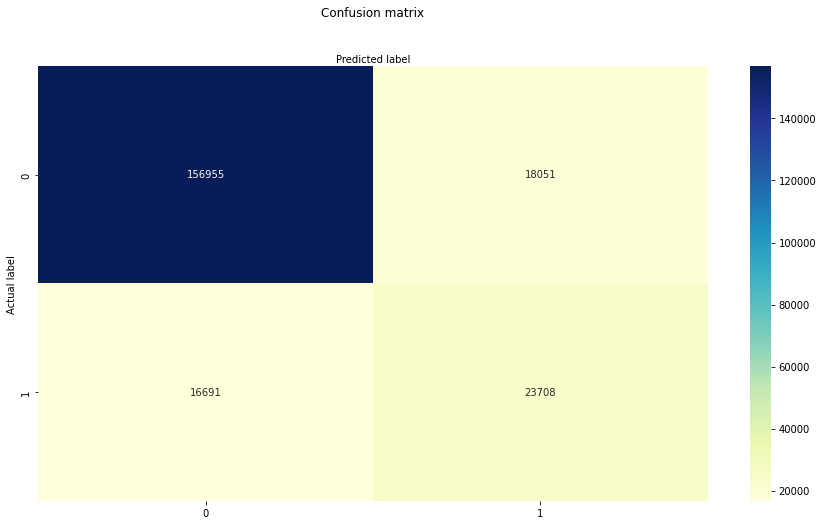

In [47]:
#visualizing confusion metrics
fig, ax = plt.subplots()
sns.heatmap(cnf_matrix3, annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
ax.xaxis.set_label_position("top")

## 3. Gradient Boosting

In [49]:
from sklearn.ensemble import GradientBoostingClassifier
#from xgboost import XGBClassifier

#creating xbb  classifier
gb_clf2 = GradientBoostingClassifier(n_estimators=500, max_depth=5, random_state=42)

#Training the model using the training sets
gb=gb_clf2.fit(df_X_train, y_train)

In [50]:

# Feature Importance of the Model
gd_importance = gb.feature_importances_
gd_importance = pd.DataFrame(gd_importance,
                                columns=["score"]).reset_index()
gd_importance["Feature"] = list(df_X_train.columns)
gd_importance.drop(columns=["index"], inplace=True)
gd_importance.sort_values(by="score",
                             ascending=False,
                             ignore_index=True,
                             inplace=True)

fig = px.bar(gd_importance, x="Feature", y="score")
fig.show()

In [51]:
#Predicting the response for test dataset
y_pred = gb_clf2.predict(df_X_eval)

#evaluate results
acc = accuracy_score(y_eval,y_pred)
prec = precision_score(y_eval,y_pred)
rec = recall_score(y_eval, y_pred)
f1 = f1_score(y_eval,y_pred)
f2 = fbeta_score(y_eval,y_pred,beta=2.0)

Model_results = pd.DataFrame([['Gradient Boosting',acc,prec,rec,f1,f2]],columns=['Model', 'Accuracy','Precision','Recall','F1 score','F2 score'])
results = results.append(Model_results,ignore_index=True)
results

,Model,Accuracy,Precision,Recall,F1 score,F2 score
0,Logistics Regression,0.857250,0.625488,0.595312,0.610027,0.601112
1,Decision Tree,0.838713,0.567734,0.586846,0.577132,0.582921
2,Gradient Boosting,0.865291,0.669810,0.555657,0.607417,0.575265


## Evaluation Model_results

In [52]:
#defining confusion metrics
cnf_matrix4 = metrics.confusion_matrix(y_eval, y_pred)
cnf_matrix4 =pd.DataFrame(cnf_matrix4).reset_index(drop =True)
cnf_matrix4

,0,1
0,163940,11066
1,17951,22448


## Visualizing Confusion Matrix using Heatmap

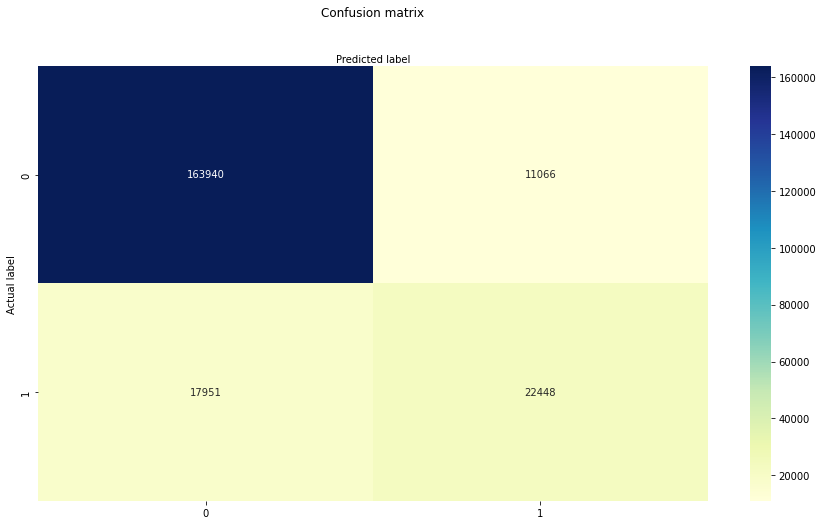

In [53]:
#visualizing confusion metrics
fig, ax = plt.subplots()
sns.heatmap(cnf_matrix4, annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
ax.xaxis.set_label_position("top")

## 4. Random Forest

In [54]:
#Import Random Forest Model
from sklearn.ensemble import RandomForestClassifier

#Create a  Classifier
clf2=RandomForestClassifier()

#Train the model using the training sets
model_train=clf2.fit(df_X_train, y_train)


In [55]:
# Feature Importance of the Model
rf_importance = model_train.feature_importances_
rf_importance = pd.DataFrame(rf_importance,
                                columns=["score"]).reset_index()
rf_importance["Feature"] = list(df_X_train.columns)
rf_importance.drop(columns=["index"], inplace=True)
rf_importance.sort_values(by="score",
                             ascending=False,
                             ignore_index=True,
                             inplace=True)

fig = px.bar(rf_importance, x="Feature", y="score")
fig.show()

In [56]:
#Predicting the response for test dataset
y_pred = model_train.predict(df_X_eval)

#evaluate results
acc = accuracy_score(y_eval,y_pred)
prec = precision_score(y_eval,y_pred)
rec = recall_score(y_eval , y_pred)
f1 = f1_score(y_eval,y_pred)
f2 = fbeta_score(y_eval,y_pred,beta=2.0)

Model_results = pd.DataFrame([['Random Forest',acc,prec,rec,f1,f2]],columns=['Model', 'Accuracy','Precision','Recall','F1 score','F2 score'])
results = results.append(Model_results,ignore_index=True)
results

,Model,Accuracy,Precision,Recall,F1 score,F2 score
0,Logistics Regression,0.857250,0.625488,0.595312,0.610027,0.601112
1,Decision Tree,0.838713,0.567734,0.586846,0.577132,0.582921
2,Gradient Boosting,0.865291,0.669810,0.555657,0.607417,0.575265
3,Random Forest,0.861215,0.649357,0.565212,0.604370,0.580250


## Evaluation Model_results

In [57]:
#defining confusion metrics
cnf_matrix5 = metrics.confusion_matrix(y_eval, y_pred)
cnf_matrix5 =pd.DataFrame(cnf_matrix5).reset_index(drop =True)
cnf_matrix5

,0,1
0,162676,12330
1,17565,22834


## Visualizing Confusion Matrix using Heatmap

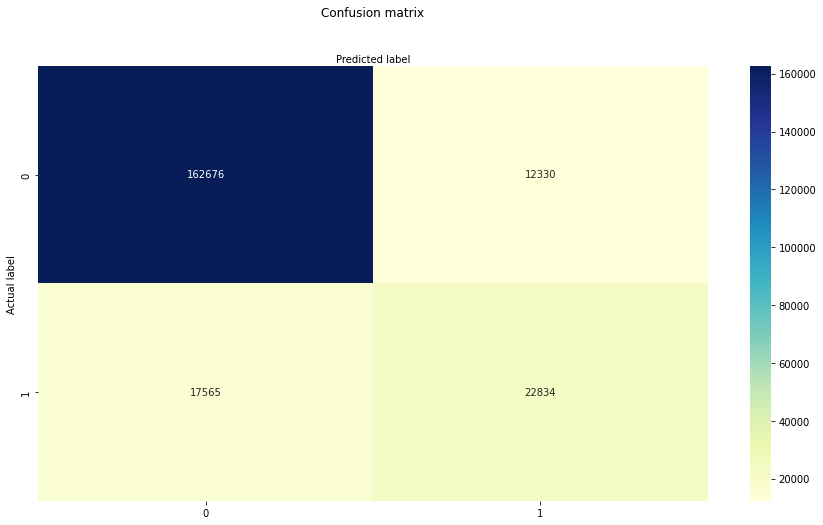

In [58]:
#visualizing confusion metrics
fig, ax = plt.subplots()
sns.heatmap(cnf_matrix5, annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
ax.xaxis.set_label_position("top")

## 6. ADABOOST

In [59]:
from sklearn.ensemble import AdaBoostClassifier

# initializing the adaBoost classifier or creating a classifier
ada = AdaBoostClassifier(random_state = 24)
# Train Adaboost Classifer
model = ada.fit(df_X_train, y_train)

In [60]:
# Feature Importance of the Model
ada_importance = model.fit(df_X_train, y_train).feature_importances_
ada_importance = pd.DataFrame(ada_importance,
                                columns=["score"]).reset_index()
ada_importance["Feature"] = list(df_X_train.columns)
ada_importance.drop(columns=["index"], inplace=True)
ada_importance.sort_values(by="score",
                             ascending=False,
                             ignore_index=True,
                             inplace=True)

fig = px.bar(ada_importance, x="Feature", y="score")
fig.show()

In [61]:
#Predict the response for test dataset
y_pred = model.predict(df_X_eval)

#evaluate results
acc = accuracy_score(y_eval,y_pred)
prec = precision_score(y_eval,y_pred)
rec = recall_score(y_eval, y_pred)
f1 = f1_score(y_eval,y_pred)
f2 = fbeta_score(y_eval,y_pred,beta=2.0)

Model_results = pd.DataFrame([['AdaBoost',acc,prec,rec,f1,f2]],columns=['Model', 'Accuracy','Precision','Recall','F1 score','F2 score'])
results = results.append(Model_results,ignore_index=True)
results

,Model,Accuracy,Precision,Recall,F1 score,F2 score
0,Logistics Regression,0.857250,0.625488,0.595312,0.610027,0.601112
1,Decision Tree,0.838713,0.567734,0.586846,0.577132,0.582921
2,Gradient Boosting,0.865291,0.669810,0.555657,0.607417,0.575265
3,Random Forest,0.861215,0.649357,0.565212,0.604370,0.580250
4,AdaBoost,0.862487,0.652646,0.570336,0.608721,0.585094


## Evaluation Model_results

In [62]:
#defining confusion metrics
cnf_matrix6 = metrics.confusion_matrix(y_eval, y_pred)
cnf_matrix6 =pd.DataFrame(cnf_matrix6).reset_index(drop =True)
cnf_matrix6

,0,1
0,162743,12263
1,17358,23041


## Visualizing Confusion Matrix using Heatmap

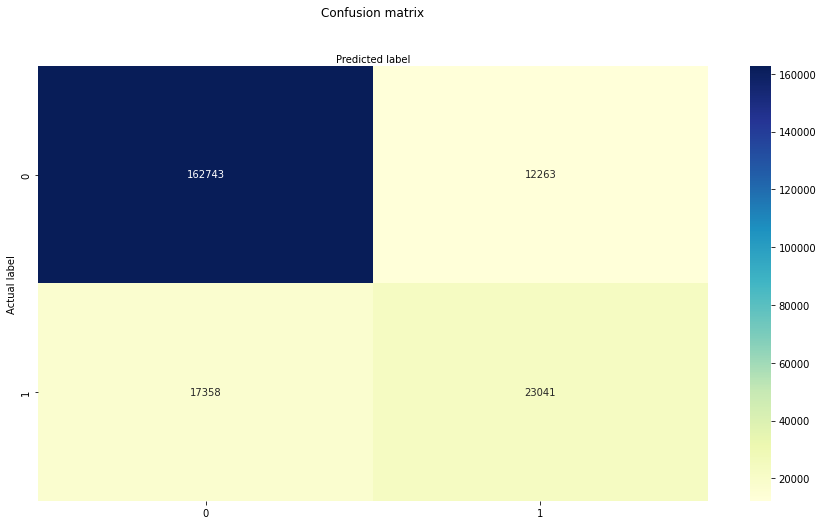

In [63]:
#visualizing confusion metrics
fig, ax = plt.subplots()
sns.heatmap(cnf_matrix6, annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
ax.xaxis.set_label_position("top")

## Model selection and Model Optimization

**From above models , we noted that the AdaBoostClassifier has the highest F1 score, ranking highest across all the 6 models, I'm only considering f1 score because I predicted on unbalance data**

## Cross-Validation and Hyperparameter tuning

### K-Fold Cross-Validation

In [64]:
# Defining the number of folds for cross-validation and the range of estimators
from sklearn.feature_selection import SelectKBest, chi2 # Univariate Selection using KBest
from sklearn.model_selection import *  #cross_val_score, fbeta_score, KFold, make_scorer, train_test_split, RandomizedSearchCV
cv = list(range(10, 21, 5))

# Using a loop to cross-validate with each number in the range of estimators
for c in cv:
    score = cross_val_score(estimator = model, X = df_X_train, y = y_train, cv=c).mean()
    
    print(f"The average score after cross-validation for the model at {c} folds is:", "{0:.5}".format(score))

The average score after cross-validation for the model at 10 folds is: 0.8625
The average score after cross-validation for the model at 15 folds is: 0.86256
The average score after cross-validation for the model at 20 folds is: 0.86225


### RandomizedSearch Cross-Validation

In [65]:

# Defining the values and instantiating the grid to be used in the RandomizedSearch
n_estimators = list(range(10, 1001, 50))
grid = {
    "n_estimators": n_estimators,
    "learning_rate" :[0.01,0.1,1,10,100],
    "random_state": [24]
    # "algorithm": [‘SAMME’, ‘SAMME.R’]
}


In [1]:
# Running the RandomizedSearch Cross-Validation with the above set of Parameters45r4
cv_model = RandomizedSearchCV(estimator= model,
                                     param_distributions= grid,
                                     n_iter= 30,
                                     cv= 10,
                                     random_state= 24,
                                     n_jobs= -1)

# Fitting the model to the training data
cv_model.fit(df_X_train, y_train)

NameError: ignored

The code below will give the best combination of hyperparameter from the above code

In [ ]:
# Looking at the best combination of hyperparameters for the model
best_params =cv_model.best_params_
print("The best combination of hyperparameters for the model will be:")
for param_name in sorted(best_params.keys()):
    print(f"{param_name} : {best_params[param_name]}")

In [ ]:
# Looking at the best score for the model during cross-validation
print("The mean cross-validated score of the model's best combination of hyperparameters is:",
      "{0:.5}".format(cv_model.best_score_))

fixed in the best combination in the code below

In [ ]:
# Defining an optimized version of the model with the best parameters
best_cv_model = AdaBoostClassifier(
                                            base_estimator=clf1
                                            learning_rate= 0.01,
                                            #max_depth= 5,
                                            n_estimators= 860,
                                            random_state= 24
                                            algorithm= 'SAMME.R’
                                           )

In [ ]:
# Fitting the model to the training data
best_cv_model= best_cv_model.fit(df_X_train, y_train)

# Predicting the test data
best_rf_pred = best_cv_model.predict(df_X_eval)

In [ ]:
from sklearn import metrics
from sklearn.metrics import *
#Evaluating the model
best_rf_report = classification_report(y_eval, best_rf_pred, target_names= ["Stayed", "Churned"])
print(best_rf_report)

# Calculating the accuracy score
accuracy = accuracy_score(y_eval, best_rf_pred)
accuracy = "{:.5f}".format(accuracy)
print("Accuracy:", accuracy)

# Calculating the F2 Score
f2_score = fbeta_score(y_eval, best_rf_pred, beta=0.5)
f2_score = "{:.5f}".format(f2_score)
print("F2 Score:", f2_score)

In [ ]:
#defining confusion metrics
cnf_matrix9 = metrics.confusion_matrix(y_eval, best_rf_pred)
cnf_matrix9 =pd.DataFrame(cnf_matrix9).reset_index(drop =True)
cnf_matrix9

In [ ]:
#visualizing confusion metrics
fig, ax = plt.subplots()
sns.heatmap(cnf_matrix9, annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
ax.xaxis.set_label_position("top")

# Future Prediction

In [ ]:
# Initializing the model (just showing it)
best_cv_model

In [ ]:
pipe = Pipeline(
    steps=[("preprocessor", preprocessor), ("estimator", best_cv_model)]
)

In [ ]:
pipe.fit(X, y)

### Applying the optimized model on the test dataset

In [ ]:
test_pred = pipe.predict(Test)

### Getting the same prediction format as the sample_submission file

In [ ]:
submission.head()

In [ ]:
submission['CHURN'] = test_pred
submission['CHURN']

In [ ]:
prediction = sub['Survived'] 


In [ ]:
prediction

In [ ]:
sub=pd.DataFrame(prediction)
sub

In [ ]:
sub.to_csv("predictions_sub.csv", index=False)

# EXPORTING MODEL

In [ ]:
ml = {'pipeline':pipe,
      'numeric_columns': numerical_columns,
      'categorical_columns': categorical_columns,}

In [ ]:
import pickle
with open("ml_comp.pkl", 'wb') as file:
    pickle.dump(ml, file)

In [ ]:
with open('ml_comp.pkl', 'rb') as file:
    loaded_object = pickle.load(file)

In [ ]:
 loaded_object